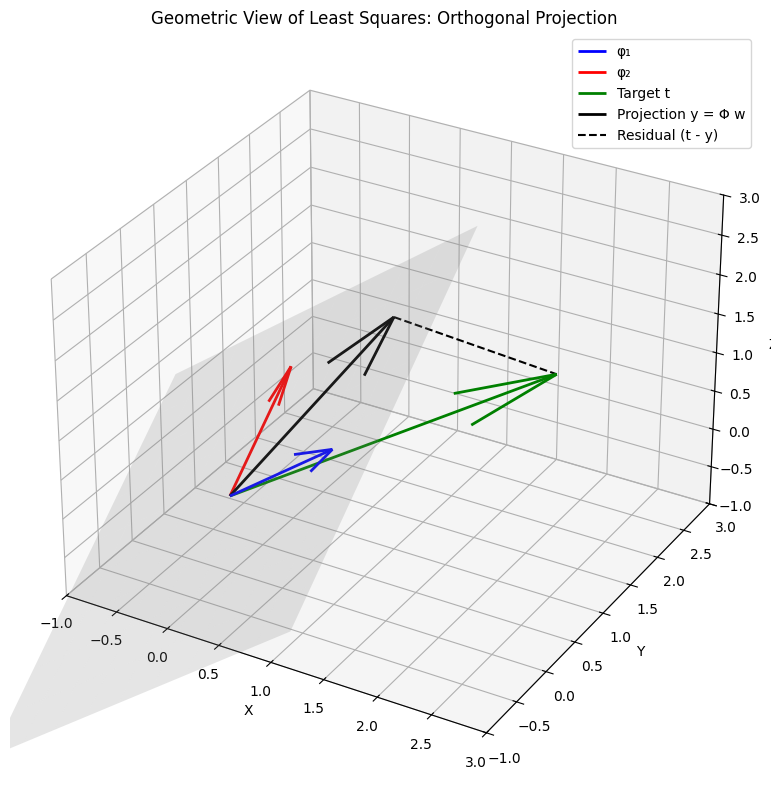

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from numpy.linalg import lstsq

# Define 3D target vector t
t = np.array([2.0, 2.0, 1.0])  # this is the observed output vector

# Define two basis vectors φ₁ and φ₂ (columns of Φ)
phi1 = np.array([1.0, 0.0, 1.0])
phi2 = np.array([0.0, 1.0, 1.0])

# Design matrix Φ ∈ ℝ^{3x2}
Phi = np.column_stack([phi1, phi2])  # shape (3, 2)

# Solve least squares: y = Φ w = projection of t onto span{φ₁, φ₂}
w_ml, *_ = lstsq(Phi, t, rcond=None)
y = Phi @ w_ml  # this is the predicted vector (orthogonal projection of t onto span)

# Plot everything
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

# Origin
O = np.zeros(3)

# Basis vectors φ₁ and φ₂
ax.quiver(*O, *phi1, color="blue", label="φ₁", linewidth=2)
ax.quiver(*O, *phi2, color="red", label="φ₂", linewidth=2)

# Target vector t
ax.quiver(*O, *t, color="green", label="Target t", linewidth=2)

# Projection y = Φ w
ax.quiver(*O, *y, color="black", label="Projection y = Φ w", linewidth=2)

# Draw line from y to t (error vector)
ax.plot([y[0], t[0]], [y[1], t[1]], [y[2], t[2]], "k--", label="Residual (t - y)")

# Draw the subspace plane spanned by φ₁ and φ₂
u = np.linspace(-1.5, 1.5, 10)
v = np.linspace(-1.5, 1.5, 10)
U, V = np.meshgrid(u, v)
plane = np.outer(phi1, U.flatten()) + np.outer(phi2, V.flatten())
X = plane[0].reshape(U.shape)
Y = plane[1].reshape(U.shape)
Z = plane[2].reshape(U.shape)
ax.plot_surface(X, Y, Z, alpha=0.2, color="gray", edgecolor="none")

# Axes labels and legend
ax.set_xlim(-1, 3)
ax.set_ylim(-1, 3)
ax.set_zlim(-1, 3)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("Geometric View of Least Squares: Orthogonal Projection")
ax.legend()
plt.tight_layout()
plt.show()